# 02. Feature Engineering — 셀 1개 = 1행 피처와 선택 규칙

- 코드: `src/features.py` (피처 계산 `build_features`, 선택 규칙 `select_features`)
- 원칙
  1. **사이클 100 이하 데이터만 사용** (조기 예측이 목표, 미래 정보 누수 방지)
  2. **피처 선택은 Train 부분만 보고** 한다 (Valid·Test 정보 누수 방지)
- EDA 근거: 100사이클 용량 숫자로는 셀 구별이 어려움(Q2) → 방전 곡선 변화 ΔQ(V)로 미세 열화를 잡음(Q3)

In [1]:
import sys, inspect
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.features import build_features, delta_q_features, CANDIDATE_FEATURES, select_features
from src.train import policy_holdout

plt.rcParams.update({'font.family': ['AppleGothic', 'Noto Sans CJK JP', 'sans-serif'], 'axes.unicode_minus': False})
pd.set_option('display.width', 200)

## 1. 피처 계산
정리된 사이클 데이터(`*_summary_clean.pkl`)와 Qdlin(`*_qdlin.pkl`)에서 셀마다 한 행을 만든다.

In [2]:
print(inspect.getsource(delta_q_features))

def delta_q_features(qdlin_cell, c_early=10, c_late=100):
    """ΔQ(V) = Q_late(V) - Q_early(V) 곡선의 통계량"""
    dq = qdlin_cell[c_late] - qdlin_cell[c_early]
    return {
        "dQ_log_var": _log_abs(np.var(dq)),      # 논문의 핵심 단일 피처
        "dQ_log_min": _log_abs(np.min(dq)),
        "dQ_log_mean": _log_abs(np.mean(dq)),
        "dQ_skew": skew(dq),
        "dQ_kurt": kurtosis(dq),
        "dQ_at_2V": dq[-1],                       # 전압 격자 마지막 점(2.0V 부근, 미확인)
    }



In [3]:
feats = {b: build_features(b) for b in ['b1', 'b2', 'b3']}   # data/processed/features_{b}.csv 저장
b1 = feats['b1']
print('결측 있는 피처:', b1[CANDIDATE_FEATURES].isna().sum()[lambda s: s > 0].to_dict() or '없음')
b1.head(3)

[b1] 36셀 × 21열 → features_b1.csv


[b2] 39셀 × 21열 → features_b2.csv


[b3] 44셀 × 21열 → features_b3.csv
결측 있는 피처: 없음


,batch,policy,QD_c2,QD_max_minus_c2,QD_c100_minus_c2,QD_slope_91_100,QD_intercept_91_100,IR_c2,IR_c100_minus_c2,Tmax_mean,...,chargetime_mean_5,dQ_log_var,dQ_log_min,dQ_log_mean,dQ_skew,dQ_kurt,dQ_at_2V,cycle_life,log_cycle_life,label_550
cell_id,,,,,,,,,,,,,,,,,,,,,
b1_c05,b1,4.4C(80%)-4.4C,1.076127,0.005944,0.003653,-0.000023,1.082085,0.016438,-0.000112,33.020007,...,10.980560,-4.155832,-1.583636,-1.937981,-0.141296,-1.192363,-0.004145,1074.0,3.031004,1
b1_c06,b1,4.8C(80%)-4.8C,1.075836,0.006303,0.003407,-0.000062,1.085485,0.017002,-0.000333,35.792631,...,10.072406,-3.771283,-1.414229,-1.791400,-0.393456,-1.210020,-0.004977,636.0,2.803457,1
b1_c07,b1,4.8C(80%)-4.8C,1.093864,0.004104,0.001898,-0.000041,1.099841,0.016311,-0.000038,35.322695,...,10.029460,-3.821834,-1.428857,-1.784616,-0.308701,-1.112407,-0.007452,870.0,2.939519,1


| 피처 | 의미 | EDA 근거 |
|---|---|---|
| `dQ_log_var`, `dQ_log_min`, `dQ_log_mean` | ΔQ(V) 분산·최소값·평균의 log | Q3 |
| `dQ_skew`, `dQ_kurt` | ΔQ(V) 곡선 모양(왜도·첨도) | Q3 |
| `dQ_at_2V` | 저전압 끝점의 ΔQ | Q3 |
| `QD_c2`, `QD_max_minus_c2`, `QD_c100_minus_c2` | 초기 용량과 초기 변화량 | Q2 |
| `QD_slope_91_100`, `QD_intercept_91_100` | 91~100사이클 용량 기울기·절편 | Q2 |
| `IR_c2`, `IR_c100_minus_c2` | 내부저항과 변화량 | Q5 |
| `Tmax_mean`, `Tavg_mean` | 온도 | Q5 |
| `chargetime_mean_5` | 처음 5사이클 평균 충전시간 | Q4 |
| `log_cycle_life` | 타깃 (`cycle_life`, `label_550`은 참고용) | Q1 |

## 2. Train(Batch1) 기준 타깃 상관

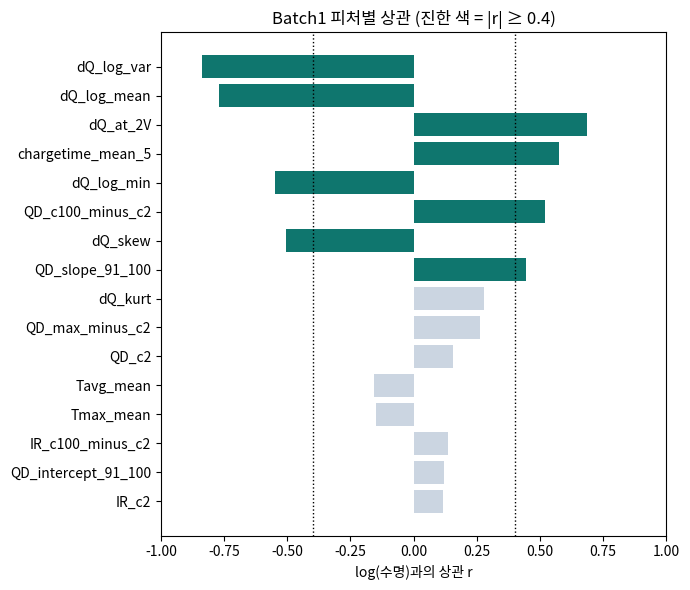

In [4]:
r = b1[CANDIDATE_FEATURES + ['log_cycle_life']].corr()['log_cycle_life'][CANDIDATE_FEATURES].sort_values(key=abs)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(r.index, r.values, color=['#0f766e' if abs(v) >= 0.4 else '#cbd5e1' for v in r.values])
for x in (-0.4, 0.4): ax.axvline(x, color='k', ls=':', lw=1)
ax.set(xlim=(-1, 1), xlabel='log(수명)과의 상관 r', title='Batch1 피처별 상관 (진한 색 = |r| ≥ 0.4)')
plt.tight_layout(); plt.show()

## 3. 선택 규칙 적용 (`select_features`)
1) 타깃과 |r| ≥ 0.4인 피처를 |r| 큰 순서로 → 2) 이미 고른 피처와 |r| > 0.85면 버림 (다중공선성)

In [5]:
print(inspect.getsource(select_features))

def select_features(train_df, target="log_cycle_life", r_min=0.4, max_pair_r=0.85):
    """
    DAY1 설계서의 선택 규칙을 코드로 고정 — 반드시 Train 부분만 넣을 것 (Valid/Test 정보 누수 방지)
    1) 타깃과 |r| >= r_min 인 피처를 |r| 큰 순서로 정렬
    2) 이미 고른 피처와 |r| > max_pair_r 이면 버림 (다중공선성)
    """
    r = train_df[CANDIDATE_FEATURES + [target]].corr()[target][CANDIDATE_FEATURES]
    corr = train_df[CANDIDATE_FEATURES].corr().abs()
    keep = []
    for c in r[r.abs() >= r_min].abs().sort_values(ascending=False).index:
        if all(corr.loc[c, k] <= max_pair_r for k in keep):
            keep.append(c)
    return keep



In [6]:
def explain(df):
    r = df[CANDIDATE_FEATURES + ['log_cycle_life']].corr()['log_cycle_life'][CANDIDATE_FEATURES]
    corr = df[CANDIDATE_FEATURES].corr().abs()
    keep, rows = [], []
    for c in r[r.abs() >= 0.4].abs().sort_values(ascending=False).index:
        clash = [(k, round(corr.loc[c, k], 2)) for k in keep if corr.loc[c, k] > 0.85]
        rows.append([c, round(r[c], 3), '제외' if clash else '선택', clash or ''])
        if not clash: keep.append(c)
    return pd.DataFrame(rows, columns=['피처', 'r', '결과', '충돌(|r|>0.85)'])

print('(a) Batch1 전체 기준 — DAY1 설계서 시점')
display(explain(b1))
tr, va = policy_holdout(b1)
print('(b) 실제 파이프라인: 정책 단위 Hold-out 후 Train 29셀 기준 →', select_features(tr))
display(explain(tr))

(a) Batch1 전체 기준 — DAY1 설계서 시점


,피처,r,결과,충돌(|r|>0.85)
0,dQ_log_var,-0.837,선택,
1,dQ_log_mean,-0.772,제외,"[(dQ_log_var, 0.98)]"
2,dQ_at_2V,0.685,제외,"[(dQ_log_var, 0.88)]"
3,chargetime_mean_5,0.574,선택,
4,dQ_log_min,-0.548,선택,
5,QD_c100_minus_c2,0.519,선택,
6,dQ_skew,-0.506,선택,
7,QD_slope_91_100,0.443,제외,"[(QD_c100_minus_c2, 0.89)]"


(b) 실제 파이프라인: 정책 단위 Hold-out 후 Train 29셀 기준 → ['dQ_log_var', 'QD_c100_minus_c2', 'dQ_skew', 'chargetime_mean_5']


,피처,r,결과,충돌(|r|>0.85)
0,dQ_log_var,-0.797,선택,
1,dQ_log_min,-0.789,제외,"[(dQ_log_var, 1.0)]"
2,dQ_log_mean,-0.739,제외,"[(dQ_log_var, 0.98)]"
3,dQ_at_2V,0.714,제외,"[(dQ_log_var, 0.91)]"
4,QD_c100_minus_c2,0.606,선택,
5,QD_slope_91_100,0.533,제외,"[(QD_c100_minus_c2, 0.91)]"
6,dQ_skew,-0.529,선택,
7,chargetime_mean_5,0.518,선택,


**시행착오 — DAY1과 구현의 불일치 발견**
- DAY1 설계서에서는 손으로 6개(`dQ_log_var, dQ_log_min, dQ_at_2V, dQ_skew, QD_slope_91_100, chargetime_mean_5`)를 골랐다
- 규칙을 코드로 그대로 적용하니 결과가 달랐다: `dQ_at_2V`는 `dQ_log_var`와 0.88로 규칙 위반, `QD_slope_91_100`보다 `QD_c100_minus_c2`가 상관이 커서 먼저 선택됨
- → 규칙을 `select_features`로 코드에 고정하고, **Train 부분에서만** 선택하도록 파이프라인 수정. 수정 전후 최종 결론(Baseline 1위)은 같음

## 4. 선택은 얼마나 안정적인가?
정책 단위 Hold-out을 20번 바꿔가며 Train 부분마다 규칙을 다시 적용 (`experiments/model_selection.py` 결과)

In [7]:
fl = pd.read_csv(ROOT / 'results' / 'feature_selection_by_seed.csv')
counts = pd.Series(','.join(fl['features']).split(',')).value_counts()
display(counts.rename('선택 횟수 (/20)').to_frame())
print('선택 피처 개수 분포:', fl['n_features'].value_counts().sort_index().to_dict())

,선택 횟수 (/20)
dQ_log_var,20
chargetime_mean_5,17
dQ_skew,17
QD_c100_minus_c2,13
dQ_log_min,13
dQ_at_2V,2
IR_c2,1
dQ_kurt,1


선택 피처 개수 분포: {2: 2, 3: 3, 4: 5, 5: 9, 6: 1}


- `dQ_log_var`만 **20번 모두** 선택되고, 나머지 피처는 분할에 따라 들어왔다 나갔다 함
- Train 29셀에서는 2순위 이하 피처의 상관이 분할 운에 크게 흔들림 → 이 피처들이 주는 정보가 불안정하다는 신호
- 이 결과가 `03_modeling.ipynb`에서 **`dQ_log_var` 1개 선형회귀(Baseline)가 가장 좋았던 이유**와 연결됨

## 5. 다중공선성 — 선택 전후 VIF

In [8]:
def vif(X):
    X = (X - X.mean()) / X.std()
    out = {}
    for c in X.columns:
        o = X.drop(columns=c)
        r2 = LinearRegression().fit(o, X[c]).score(o, X[c])
        out[c] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out).sort_values(ascending=False).round(1)

sel = select_features(tr)
print('후보 전체 VIF 상위 5:'); display(vif(tr[CANDIDATE_FEATURES]).head())
print('선택 후 VIF:'); display(vif(tr[sel]))

후보 전체 VIF 상위 5:


QD_c2                  27303.7
QD_intercept_91_100    25847.2
QD_slope_91_100         7075.4
QD_c100_minus_c2        3314.3
dQ_log_min              1157.7
dtype: float64

선택 후 VIF:


dQ_log_var           3.2
QD_c100_minus_c2     2.8
dQ_skew              2.1
chargetime_mean_5    1.7
dtype: float64

## 6. 정리
- 피처: ΔQ(V) 통계량 중심, 사이클 100 이하만 사용
- 선택: 규칙(|r| ≥ 0.4, 서로 |r| > 0.85면 하나만)을 코드로 고정, Train 부분에서만 적용 → 다중공선성 크게 감소 (VIF 수만 → 한 자릿수)
- 가장 확실한 신호는 `dQ_log_var` 하나 (분할 20번 모두 선택, r = −0.84)